In [1]:
# 导入数据处理库
import pandas as pd
import numpy as np

# 导入可视化库
import matplotlib.pyplot as plt
import seaborn as sns

# 导入模型和评估指标
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
df = pd.read_csv('train.csv')

# 查看数据前5行
print("数据前5行：")
print(df.head())

# 查看数据基本信息
print("\n数据基本信息：")
print(df.info())

# 查看目标变量分布
print("\n目标变量分布：")
print(df['target'].value_counts())
print(f"5G用户占比：{df['target'].mean():.2%}")

数据前5行：
   id  cat_0  cat_1  cat_2  cat_3  cat_4  cat_5  cat_6  cat_7  cat_8  ...  \
0   0      2    103      9      4      3      1      3      4      4  ...   
1   1      0    177      6      2      2      1      2      4      4  ...   
2   2      7     70      7      4      5      0      3      4      4  ...   
3   3     11    166      7      2      3      1      1      1      2  ...   
4   4      0    178     10      4      3      0      4      4      4  ...   

      num_29  num_30    num_31  num_32  num_33  num_34  num_35       num_36  \
0   2.000000     3.0  0.000000     0.0     0.0     0.0     0.0     0.089758   
1   0.968742     0.0  0.000000     0.0     0.0     0.0     0.0     0.000000   
2   0.000000     0.0  0.000000     0.0     0.0     0.0     0.0     0.000000   
3   0.021729     0.0  0.021729     0.0     0.0     0.0     0.0     0.000081   
4  30.000000    30.0  0.000000     0.0     0.0     0.0     0.0  6127.621124   

     num_37  target  
0  0.000129     0.0  
1  0.000312

In [2]:
# 1. 分离特征和目标变量
X = df.drop(['id', 'target'], axis=1)  # 去掉id和目标列，剩下的都是特征
y = df['target']  # 目标变量

# 2. 分离离散特征和数值特征
cat_features = [col for col in X.columns if col.startswith('cat_')]
num_features = [col for col in X.columns if col.startswith('num_')]

print(f"离散特征数量：{len(cat_features)}")
print(f"数值特征数量：{len(num_features)}")

# 3. 处理缺失值（LightGBM自动处理缺失值，这里只做最简单的填充）
# 离散特征用众数填充
for col in cat_features:
    X[col] = X[col].fillna(X[col].mode()[0])

# 数值特征用中位数填充
for col in num_features:
    X[col] = X[col].fillna(X[col].median())

# 4. 划分训练集和测试集（7:3划分）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n训练集大小：{X_train.shape}")
print(f"测试集大小：{X_test.shape}")

离散特征数量：20
数值特征数量：38

训练集大小：(560000, 58)
测试集大小：(240000, 58)


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 1. 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. 优化逻辑回归参数
lr_model = LogisticRegression(
    solver="saga",    # 收敛更稳定的优化器
    max_iter=10000,   # 大幅提高迭代上限
    C=0.5,            # 适度加强正则，避免参数爆炸
    random_state=42
)

# 3. 训练模型
lr_model.fit(X_train_scaled, y_train)

# 4. 预测
y_pred_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_lr_class = lr_model.predict(X_test_scaled)

# 5. 多维度评估
auc_lr = roc_auc_score(y_test, y_pred_lr)
ap_lr = average_precision_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr_class)
recall_lr = recall_score(y_test, y_pred_lr_class)
f1_lr = f1_score(y_test, y_pred_lr_class)

print("=" * 65)
print("  逻辑回归模型评估")
print("=" * 65)
print(f"  AUC (ROC曲线下面积)        : {auc_lr:.4f}  【越大越好，上限1.0，0.5=随机猜】")
print(f"  Average Precision (PR下面积): {ap_lr:.4f}  【越大越好，上限1.0，基线≈{y_test.mean():.4f}(正样本比例)】")
print(f"  Precision (精确率/查准率)   : {precision_lr:.4f}  【越大越好，预测为5G用户中真正是的比例】")
print(f"  Recall    (召回率/查全率)   : {recall_lr:.4f}  【越大越好，真正的5G用户被找出来的比例】")
print(f"  F1 Score  (F1分数)         : {f1_lr:.4f}  【越大越好，Precision与Recall的调和平均】")
print()
print(f"  ⚠ 当前正样本仅占{y_test.mean():.2%}，AUC好看但Recall极低是典型的'高AUC低召回'陷阱。")
print(f"  请重点关注 Average Precision 和 Recall，它们才对不平衡数据诚实。")
print()
print(f"  混淆矩阵（行=真实标签, 列=预测标签）：")
cm = confusion_matrix(y_test, y_pred_lr_class)
print(f"              预测非5G  预测5G")
print(f"  真实非5G:  {cm[0,0]:>8}  {cm[0,1]:>6}")
print(f"  真实5G:    {cm[1,0]:>8}  {cm[1,1]:>6}")
print(f"\n  分类报告：")
print(classification_report(y_test, y_pred_lr_class, target_names=['非5G用户', '5G用户']))

  逻辑回归模型评估
  AUC (ROC曲线下面积)        : 0.8352  【越大越好，上限1.0，0.5=随机猜】
  Average Precision (PR下面积): 0.0703  【越大越好，上限1.0，基线≈0.0132(正样本比例)】
  Precision (精确率/查准率)   : 0.0870  【越大越好，预测为5G用户中真正是的比例】
  Recall    (召回率/查全率)   : 0.0013  【越大越好，真正的5G用户被找出来的比例】
  F1 Score  (F1分数)         : 0.0025  【越大越好，Precision与Recall的调和平均】

  ⚠ 当前正样本仅占1.32%，AUC好看但Recall极低是典型的'高AUC低召回'陷阱。
  请重点关注 Average Precision 和 Recall，它们才对不平衡数据诚实。

  混淆矩阵（行=真实标签, 列=预测标签）：
              预测非5G  预测5G
  真实非5G:    236778      42
  真实5G:        3176       4

  分类报告：
              precision    recall  f1-score   support

       非5G用户       0.99      1.00      0.99    236820
        5G用户       0.09      0.00      0.00      3180

    accuracy                           0.99    240000
   macro avg       0.54      0.50      0.50    240000
weighted avg       0.97      0.99      0.98    240000



In [4]:
# 1. 创建LightGBM模型（先用默认参数）
lgb_model = LGBMClassifier(random_state=42, verbose=-1)

# 2. 训练模型
lgb_model.fit(X_train, y_train)

# 3. 预测
y_pred_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb_class = lgb_model.predict(X_test)

# 4. 多维度评估
auc_lgb = roc_auc_score(y_test, y_pred_lgb)
ap_lgb = average_precision_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb_class)
recall_lgb = recall_score(y_test, y_pred_lgb_class)
f1_lgb = f1_score(y_test, y_pred_lgb_class)

print("=" * 65)
print("  LightGBM模型（默认参数）评估")
print("=" * 65)
print(f"  AUC (ROC曲线下面积)        : {auc_lgb:.4f}  【越大越好，上限1.0，0.5=随机猜】")
print(f"  Average Precision (PR下面积): {ap_lgb:.4f}  【越大越好，上限1.0，基线≈{y_test.mean():.4f}(正样本比例)】")
print(f"  Precision (精确率/查准率)   : {precision_lgb:.4f}  【越大越好，预测为5G用户中真正是的比例】")
print(f"  Recall    (召回率/查全率)   : {recall_lgb:.4f}  【越大越好，真正的5G用户被找出来的比例】")
print(f"  F1 Score  (F1分数)         : {f1_lgb:.4f}  【越大越好，Precision与Recall的调和平均】")
print()
print(f"  ⚠ 当前正样本仅占{y_test.mean():.2%}，AUC好看但Recall极低是典型的'高AUC低召回'陷阱。")
print(f"  请重点关注 Average Precision 和 Recall，它们才对不平衡数据诚实。")
print()
print(f"  混淆矩阵（行=真实标签, 列=预测标签）：")
cm = confusion_matrix(y_test, y_pred_lgb_class)
print(f"              预测非5G  预测5G")
print(f"  真实非5G:  {cm[0,0]:>8}  {cm[0,1]:>6}")
print(f"  真实5G:    {cm[1,0]:>8}  {cm[1,1]:>6}")
print(f"\n  分类报告：")
print(classification_report(y_test, y_pred_lgb_class, target_names=['非5G用户', '5G用户']))

  LightGBM模型（默认参数）评估
  AUC (ROC曲线下面积)        : 0.9054  【越大越好，上限1.0，0.5=随机猜】
  Average Precision (PR下面积): 0.1213  【越大越好，上限1.0，基线≈0.0132(正样本比例)】
  Precision (精确率/查准率)   : 0.1322  【越大越好，预测为5G用户中真正是的比例】
  Recall    (召回率/查全率)   : 0.0123  【越大越好，真正的5G用户被找出来的比例】
  F1 Score  (F1分数)         : 0.0224  【越大越好，Precision与Recall的调和平均】

  ⚠ 当前正样本仅占1.32%，AUC好看但Recall极低是典型的'高AUC低召回'陷阱。
  请重点关注 Average Precision 和 Recall，它们才对不平衡数据诚实。

  混淆矩阵（行=真实标签, 列=预测标签）：
              预测非5G  预测5G
  真实非5G:    236564     256
  真实5G:        3141      39

  分类报告：
              precision    recall  f1-score   support

       非5G用户       0.99      1.00      0.99    236820
        5G用户       0.13      0.01      0.02      3180

    accuracy                           0.99    240000
   macro avg       0.56      0.51      0.51    240000
weighted avg       0.98      0.99      0.98    240000



In [5]:
# 调整后的LightGBM模型
lgb_model_tuned = LGBMClassifier(
    n_estimators=200,  # 树的数量
    max_depth=5,       # 树的最大深度
    learning_rate=0.1, # 学习率
    subsample=0.8,     # 每次训练用80%的样本
    colsample_bytree=0.8, # 每次训练用80%的特征
    random_state=42,
    verbose=-1
)

# 训练调优后的模型
lgb_model_tuned.fit(X_train, y_train)

# 预测
y_pred_lgb_tuned = lgb_model_tuned.predict_proba(X_test)[:, 1]
y_pred_lgb_tuned_class = lgb_model_tuned.predict(X_test)

# 多维度评估
auc_lgb_tuned = roc_auc_score(y_test, y_pred_lgb_tuned)
ap_lgb_tuned = average_precision_score(y_test, y_pred_lgb_tuned)
precision_lgb_tuned = precision_score(y_test, y_pred_lgb_tuned_class)
recall_lgb_tuned = recall_score(y_test, y_pred_lgb_tuned_class)
f1_lgb_tuned = f1_score(y_test, y_pred_lgb_tuned_class)

print("=" * 65)
print("  LightGBM模型（调优后）评估")
print("=" * 65)
print(f"  AUC (ROC曲线下面积)        : {auc_lgb_tuned:.4f}  【越大越好，上限1.0，0.5=随机猜】")
print(f"  Average Precision (PR下面积): {ap_lgb_tuned:.4f}  【越大越好，上限1.0，基线≈{y_test.mean():.4f}(正样本比例)】")
print(f"  Precision (精确率/查准率)   : {precision_lgb_tuned:.4f}  【越大越好，预测为5G用户中真正是的比例】")
print(f"  Recall    (召回率/查全率)   : {recall_lgb_tuned:.4f}  【越大越好，真正的5G用户被找出来的比例】")
print(f"  F1 Score  (F1分数)         : {f1_lgb_tuned:.4f}  【越大越好，Precision与Recall的调和平均】")
print()
print(f"  ⚠ 当前正样本仅占{y_test.mean():.2%}，AUC好看但Recall极低是典型的'高AUC低召回'陷阱。")
print(f"  请重点关注 Average Precision 和 Recall，它们才对不平衡数据诚实。")
print()
print(f"  混淆矩阵（行=真实标签, 列=预测标签）：")
cm = confusion_matrix(y_test, y_pred_lgb_tuned_class)
print(f"              预测非5G  预测5G")
print(f"  真实非5G:  {cm[0,0]:>8}  {cm[0,1]:>6}")
print(f"  真实5G:    {cm[1,0]:>8}  {cm[1,1]:>6}")
print(f"\n  分类报告：")
print(classification_report(y_test, y_pred_lgb_tuned_class, target_names=['非5G用户', '5G用户']))

  LightGBM模型（调优后）评估
  AUC (ROC曲线下面积)        : 0.9128  【越大越好，上限1.0，0.5=随机猜】
  Average Precision (PR下面积): 0.1448  【越大越好，上限1.0，基线≈0.0132(正样本比例)】
  Precision (精确率/查准率)   : 0.2742  【越大越好，预测为5G用户中真正是的比例】
  Recall    (召回率/查全率)   : 0.0053  【越大越好，真正的5G用户被找出来的比例】
  F1 Score  (F1分数)         : 0.0105  【越大越好，Precision与Recall的调和平均】

  ⚠ 当前正样本仅占1.32%，AUC好看但Recall极低是典型的'高AUC低召回'陷阱。
  请重点关注 Average Precision 和 Recall，它们才对不平衡数据诚实。

  混淆矩阵（行=真实标签, 列=预测标签）：
              预测非5G  预测5G
  真实非5G:    236775      45
  真实5G:        3163      17

  分类报告：
              precision    recall  f1-score   support

       非5G用户       0.99      1.00      0.99    236820
        5G用户       0.27      0.01      0.01      3180

    accuracy                           0.99    240000
   macro avg       0.63      0.50      0.50    240000
weighted avg       0.98      0.99      0.98    240000



  模型性能对比（↑ = 越大越好）
          模型    AUC ↑  AvgPrecision ↑  Precision ↑  Recall ↑     F1 ↑
        逻辑回归 0.835234        0.070335     0.086957  0.001258 0.002480
LightGBM(默认) 0.905423        0.121273     0.132203  0.012264 0.022446
LightGBM(调优) 0.912767        0.144754     0.274194  0.005346 0.010487

【指标速查】
  AUC:               模型排序能力，0.5=随机, 1.0=完美。不平衡数据上容易虚高。
  Average Precision: PR曲线下面积，比AUC对不平衡数据更诚实，低于正样本比例就没意义。
  Precision:         预测为「5G用户」的样本中，真正的5G用户占比。
  Recall:            所有真正的5G用户中，被模型成功找出的比例。
  F1 Score:          Precision和Recall的调和平均，两者都很重要时看这个。



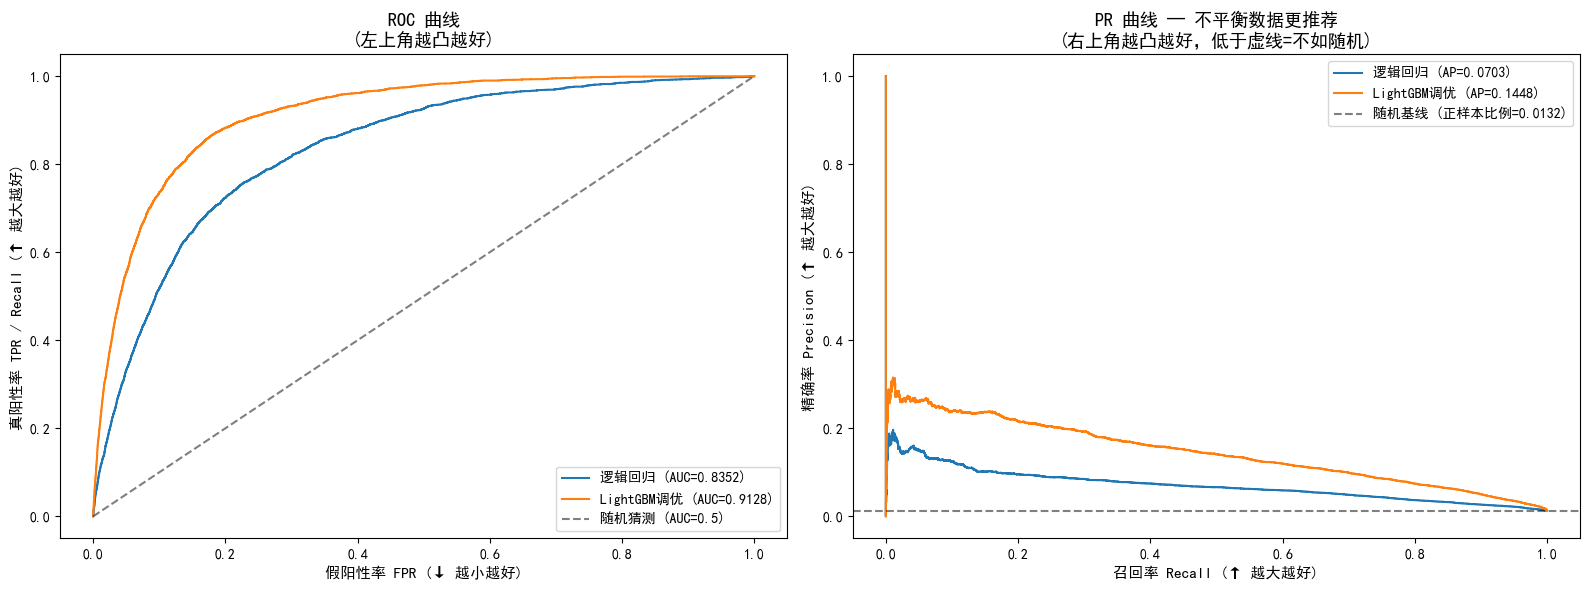

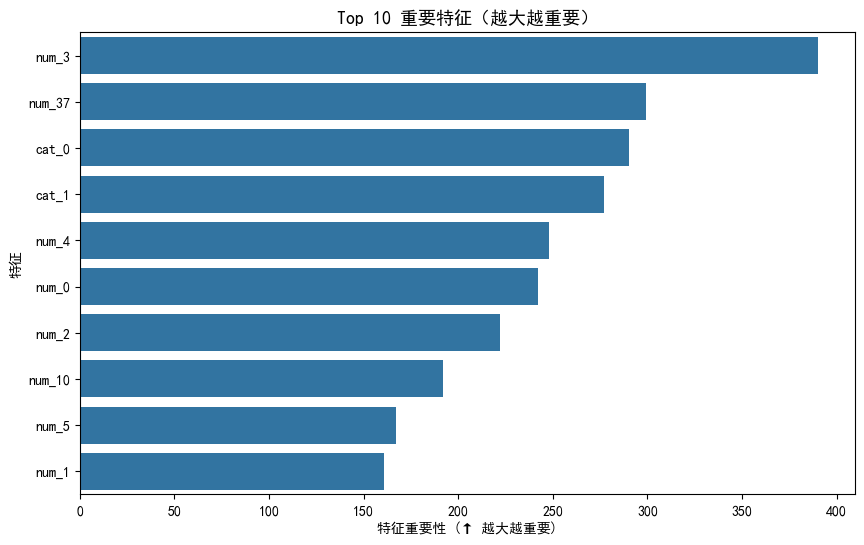

In [6]:
# ============================================================================
# 1. 模型性能对比表（多维指标）
# ============================================================================
results = pd.DataFrame({
    '模型':       ['逻辑回归',       'LightGBM(默认)',       'LightGBM(调优)'],
    'AUC ↑':     [auc_lr,           auc_lgb,                auc_lgb_tuned],
    'AvgPrecision ↑': [ap_lr,       ap_lgb,                 ap_lgb_tuned],
    'Precision ↑': [precision_lr,   precision_lgb,          precision_lgb_tuned],
    'Recall ↑':  [recall_lr,        recall_lgb,             recall_lgb_tuned],
    'F1 ↑':      [f1_lr,            f1_lgb,                 f1_lgb_tuned]
})

print("=" * 80)
print("  模型性能对比（↑ = 越大越好）")
print("=" * 80)
print(results.to_string(index=False))
print()
print("【指标速查】")
print("  AUC:               模型排序能力，0.5=随机, 1.0=完美。不平衡数据上容易虚高。")
print("  Average Precision: PR曲线下面积，比AUC对不平衡数据更诚实，低于正样本比例就没意义。")
print("  Precision:         预测为「5G用户」的样本中，真正的5G用户占比。")
print("  Recall:            所有真正的5G用户中，被模型成功找出的比例。")
print("  F1 Score:          Precision和Recall的调和平均，两者都很重要时看这个。")
print()

# ============================================================================
# 2. 绘制 ROC曲线 + PR曲线（并排）
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 左图：ROC 曲线 ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_lgb_tuned)

axes[0].plot(fpr_lr, tpr_lr, label=f'逻辑回归 (AUC={auc_lr:.4f})')
axes[0].plot(fpr_lgb, tpr_lgb, label=f'LightGBM调优 (AUC={auc_lgb_tuned:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='随机猜测 (AUC=0.5)')
axes[0].set_xlabel('假阳性率 FPR (↓ 越小越好)', fontsize=11)
axes[0].set_ylabel('真阳性率 TPR / Recall (↑ 越大越好)', fontsize=11)
axes[0].set_title('ROC 曲线\n(左上角越凸越好)', fontsize=13)
axes[0].legend(loc='lower right')

# --- 右图：PR 曲线（更适合不平衡数据） ---
precision_lr_curve, recall_lr_curve, _ = precision_recall_curve(y_test, y_pred_lr)
precision_lgb_curve, recall_lgb_curve, _ = precision_recall_curve(y_test, y_pred_lgb_tuned)

axes[1].plot(recall_lr_curve, precision_lr_curve, label=f'逻辑回归 (AP={ap_lr:.4f})')
axes[1].plot(recall_lgb_curve, precision_lgb_curve, label=f'LightGBM调优 (AP={ap_lgb_tuned:.4f})')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5,
                label=f'随机基线 (正样本比例={y_test.mean():.4f})')
axes[1].set_xlabel('召回率 Recall (↑ 越大越好)', fontsize=11)
axes[1].set_ylabel('精确率 Precision (↑ 越大越好)', fontsize=11)
axes[1].set_title('PR 曲线 — 不平衡数据更推荐\n(右上角越凸越好，低于虚线=不如随机)', fontsize=13)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('roc曲线.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 3. 绘制特征重要性（LightGBM）
# ============================================================================
feature_importance = pd.DataFrame({
    '特征': X.columns,
    '重要性': lgb_model_tuned.feature_importances_
}).sort_values('重要性', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='重要性', y='特征', data=feature_importance)
plt.title('Top 10 重要特征（越大越重要）', fontsize=13)
plt.xlabel('特征重要性 (↑ 越大越重要)')
plt.savefig('特征重要性.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
import joblib

# 保存调优后的LightGBM模型
joblib.dump(lgb_model_tuned, 'lgb_model_tuned.pkl')

print("模型已保存为 lgb_model_tuned.pkl")

模型已保存为 lgb_model_tuned.pkl
